In [1]:


import numpy as np 
import pandas as pd 


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/custom.css
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/outputs/results/lgb56_confusion_matrix.png
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/outputs/results/lgb_classification_report.csv
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/outputs/results/lgb_metrics.csv
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/outputs/models/lgb_56.pkl
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/outputs/feature_selection/correlation/correlation_reduced_features.pkl
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/outputs/feature_selection/correlation/group_representatives.csv
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__results___files

In [2]:
import joblib
import numpy as np
import pandas as pd

X_train, X_test, y_train, y_test = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl"
)

print(X_train.shape)
print(X_test.shape)

(5055991, 77)
(1263998, 77)


In [3]:
feature_names = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/3-feature-selection/outputs/features/feature_names.pkl"
)

print(len(feature_names))

77


In [4]:
X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

In [5]:
correlation_reduced_features = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/outputs/feature_selection/correlation/correlation_reduced_features.pkl"
)

print("Selected features:", len(correlation_reduced_features))

Selected features: 56


In [6]:
X_train_corr = X_train_df[
    correlation_reduced_features
]

X_test_corr = X_test_df[
    correlation_reduced_features
]

print("Train:", X_train_corr.shape)
print("Test :", X_test_corr.shape)

Train: (5055991, 56)
Test : (1263998, 56)


In [7]:
from xgboost import XGBClassifier

xgb_56 = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

In [8]:
import time

In [9]:
start = time.time()

xgb_56.fit(
    X_train_corr,
    y_train
)

xgb_time = (time.time() - start) / 60

print(f"XGBoost training time: {xgb_time:.2f} minutes")

XGBoost training time: 42.04 minutes


In [10]:
y_pred_xgb_56 = xgb_56.predict(X_test_corr)
y_prob_xgb_56 = xgb_56.predict_proba(X_test_corr)

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

xgb_accuracy_56 = accuracy_score(
    y_test,
    y_pred_xgb_56
)

In [12]:


xgb_precision_56 = precision_score(
    y_test,
    y_pred_xgb_56,
    average="weighted",
    zero_division=0
)

xgb_recall_56 = recall_score(
    y_test,
    y_pred_xgb_56,
    average="weighted",
    zero_division=0
)

xgb_f1_56 = f1_score(
    y_test,
    y_pred_xgb_56,
    average="weighted",
    zero_division=0
)

xgb_mcc_56 = matthews_corrcoef(
    y_test,
    y_pred_xgb_56
)

xgb_auc_56 = roc_auc_score(
    y_test,
    y_prob_xgb_56,
    multi_class="ovr",
    average="weighted"
)

print(f"Accuracy : {xgb_accuracy_56:.4f}")
print(f"Precision: {xgb_precision_56:.4f}")
print(f"Recall   : {xgb_recall_56:.4f}")
print(f"F1-score : {xgb_f1_56:.4f}")
print(f"MCC      : {xgb_mcc_56:.4f}")
print(f"AUC      : {xgb_auc_56:.4f}")

Accuracy : 0.9819
Precision: 0.9754
Recall   : 0.9819
F1-score : 0.9743
MCC      : 0.9501
AUC      : 0.9921


In [13]:
from sklearn.metrics import classification_report

attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]
print(classification_report(
    y_test,
    y_pred_xgb_56,
    labels=range(15),
    target_names=attack_names,
    zero_division=0
))

                          precision    recall  f1-score   support

                  Benign       0.98      1.00      0.99    998829
                     Bot       1.00      1.00      1.00     28907
        Brute Force -Web       0.91      0.70      0.79       111
        Brute Force -XSS       1.00      0.64      0.78        45
        DDOS attack-HOIC       1.00      1.00      1.00     39772
    DDoS attack-LOIC-UDP       0.86      0.88      0.87       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115073
   DoS attacks-GoldenEye       1.00      1.00      1.00      8281
        DoS attacks-Hulk       1.00      1.00      1.00     29040
DoS attacks-SlowHTTPTest       0.31      0.45      0.37        11
   DoS attacks-Slowloris       0.99      0.99      0.99      1982
          FTP-BruteForce       0.14      0.10      0.12        10
            Infiltration       0.59      0.04      0.08     22764
           SQL Injection       1.00      0.71      0.83        17
         

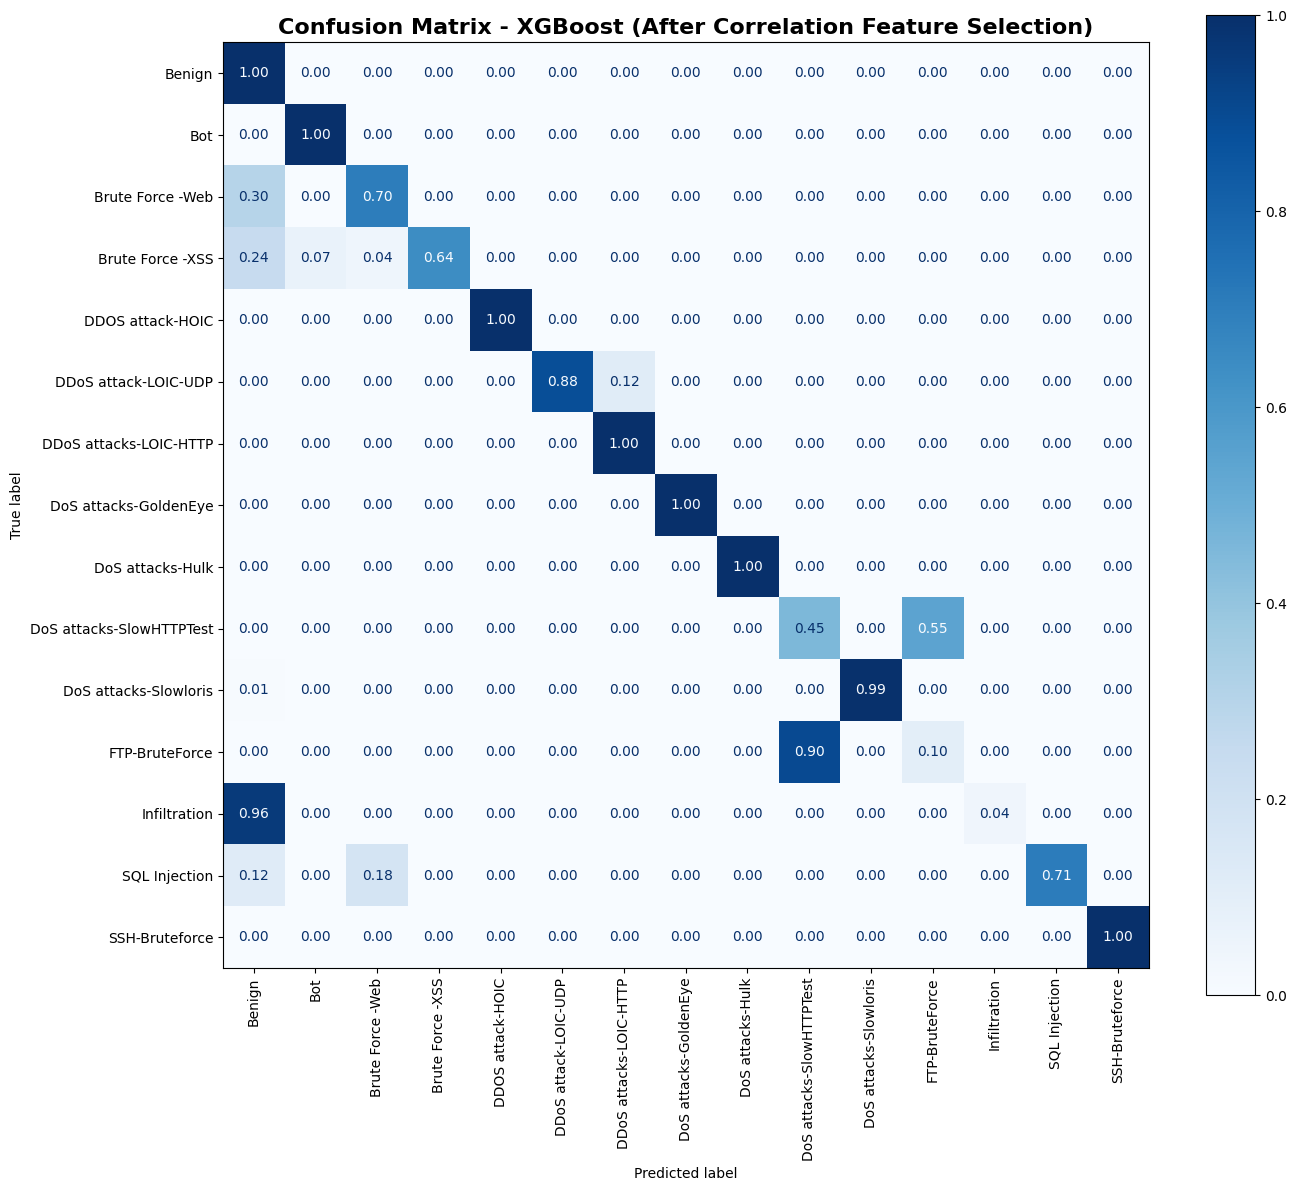

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb_56,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Confusion Matrix - XGBoost (After Correlation Feature Selection)",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

In [15]:
import os

os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

In [16]:
import joblib

joblib.dump(
    xgb_56,
    "outputs/models/lgb_56.pkl"
)

print("xgb_56 model saved!")

xgb_56 model saved!


In [17]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [xgb_accuracy_56],
    "Precision": [xgb_precision_56],
    "Recall": [xgb_recall_56],
    "F1": [xgb_f1_56],
    "MCC": [xgb_mcc_56],
    "AUC": [xgb_auc_56]
})

metrics_df.to_csv(
    "outputs/results/xgb_metrics.csv",
    index=False
)

print(metrics_df)

     Model  Accuracy  Precision    Recall        F1       MCC       AUC
0  XGBoost  0.981934    0.97541  0.981934  0.974316  0.950064  0.992104


In [18]:
attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]
report = classification_report(
    y_test,
    y_pred_xgb_56,
    labels=range(15),
    target_names=attack_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "outputs/results/xgb_classification_report.csv"
)

print("Classification Report Saved!")

Classification Report Saved!


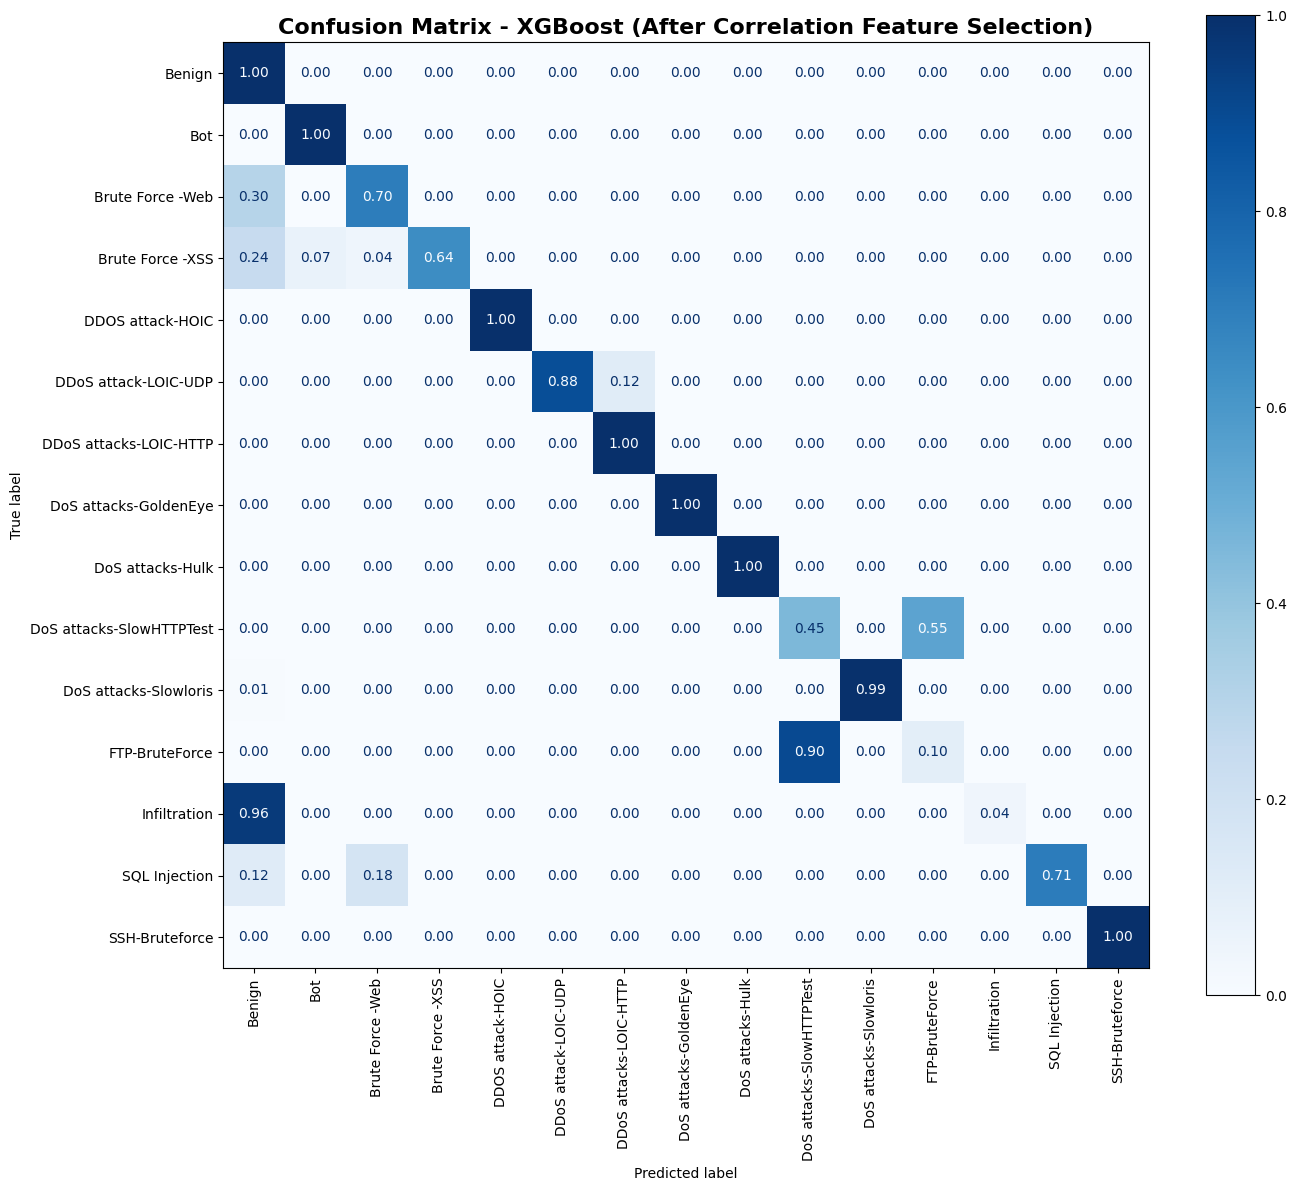

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb_56,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Confusion Matrix - XGBoost (After Correlation Feature Selection)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "outputs/results/Xgb56_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()